<a href="https://colab.research.google.com/github/Iamjohnko/Data-science-Project-Portfolio/blob/main/Upstream_Financial_and_Production_Analysis_of_Oil_%26_Gas_Fields.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Overview**:
The primary objective of this project was to assess the economic viability and long-term financial performance of three oil and gas fields—Alpha Field, Beta Deepwater, and Gamma Onshore, under a production decline scenario. This required calculating key financial metrics (NPV, IRR, Payback Period) considering the impact of decline, and understanding the sensitivity and uncertainty of these outcomes to critical parameters for robust decision-making.

# **Methodologies Employed:**
To address the problem statement, a multi-faceted analytical approach was undertaken:



*   Production Decline Modeling: The Arps decline model was applied to forecast future production, incorporating both exponential and hyperbolic decline characteristics.

*   Initial Financial Metrics: Net Present Value (NPV), Internal Rate of Return (IRR), and Payback Period were calculated. A hypothetical initial Capital Expenditure (CAPEX) of $1 Billion USD was introduced to enable meaningful calculation of these metrics, transforming previously undefined IRR and immediate payback periods into quantifiable results.

*   Advanced Financial Metrics:

  a. Profitability Index (PI): Assessed the value created per unit of investment.
  b. Return on Investment (ROI): Measured the efficiency of investment.
  c. Breakeven Oil Price: Identified the minimum oil price required for project profitability, crucial for risk assessment.


*   Sensitivity Analysis:
   a. Single-Variable Sensitivity (Decline Rate Di): Examined the impact of varying the annual decline rate on project NPV.

   b. Multi-Variable Sensitivity (Tornado Charts): Identified the most impactful variables on NPV by systematically varying key parameters (e.g., Oil Price Factor, CAPEX, Decline Rate, Tax Factor) within defined ranges.



*   Uncertainty Analysis
   a. Monte Carlo Simulation (1000 iterations): Quantified the probability distribution of NPV for each project by sampling uncertain variables (e.g., oil price, CAPEX, decline rates, discount rate) from their defined ranges. This provided mean, median, P10, P90 NPVs, and probability of positive NPV.

   b. Scenario Planning: Evaluated project performance under distinct 'Base Case,' 'Optimistic,' and 'Pessimistic' future conditions, adjusting multiple parameters simultaneously.

*   Real Options Analysis:
   Option Value to Defer: Applied the Black-Scholes model to estimate the strategic value of managerial flexibility to postpone investment decisions, resulting in an 'Expanded NPV' (Traditional NPV + Option Value).




# **Key Findings:**



1.   Oil Price Dominance: Across all analyses (Sensitivity, Monte Carlo, Scenarios), the Oil Price Factor consistently emerged as the most critical variable influencing project Net Present Value. This underscores the inherent price risk in the oil and gas sector.

1.   Impact of Decline Rate & Tax: The Decline Rate (Di) and Tax Factor were identified as the next most significant parameters, highlighting the importance of accurate production forecasting and a stable fiscal regime.
2.   CAPEX Sensitivity: Both initial and ongoing CAPEX demonstrated a clear impact, reinforcing the need for diligent cost management.


2.   Project Differentiation:


*   Gamma Onshore: Consistently demonstrated the highest mean NPV (approx. $2.01 billion), highest probability of positive NPV (80%), highest PI (5.89), and highest ROI (924.61%). Its breakeven oil price was competitive ($$2.01 billion), highest probability of positive NPV (80%), highest PI (5.89), and highest ROI (924.61%). Its breakeven oil price was competitive ($71.46/bbl), and its Expanded NPV was the highest (approx. $9.80 billion), indicating robust financial performance and strategic flexibility.

*   Alpha Field: Showed strong economic viability with a significant mean NPV (approx. $$9.80 billion), indicating robust financial performance and strategic flexibility.

Alpha Field:  Showed strong economic viability with a significant mean NPV (approx. $1.64 billion), 76% probability of positive NPV, and the lowest breakeven oil price ($66.61/bbl), suggesting good resilience. Its Expanded NPV was also substantial (approx. $$66.61/bbl), suggesting good resilience. Its Expanded NPV was also substantial (approx. $8.81 billion).


*   Beta Deepwater: Presented the highest risk profile, with the lowest mean NPV (approx. $1.06 million) and only a 48% probability of a positive NPV in the Monte Carlo simulation. It was the most sensitive to pessimistic scenarios (resulting in negative NPV) and had the highest breakeven oil price ($$1.06 million) and only a 48% probability of a positive NPV in the Monte Carlo simulation. It was the most sensitive to pessimistic scenarios (resulting in negative NPV) and had the highest breakeven oil price ($85.41/bbl). While the option to defer added value, its fundamental economic indicators were weaker.








# **Conclusion and Recommendation:**

Based on a holistic evaluation integrating traditional financial metrics with advanced risk and uncertainty analyses, Gamma Onshore is the most attractive project. Its superior expected value, higher probability of success, strong profitability indicators, and significant strategic option value consistently position it as the most robust investment. Alpha Field is a strong second choice, demonstrating solid economics and resilience. Beta Deepwater, however, carries the highest risk and lowest expected returns under various uncertain conditions, making it the least favorable for execution.



In [ ]:
import pandas as pd
import numpy as np

# Load dataset (use your downloaded path)
df = pd.read_csv("upstream_financial_model_dataset.csv")

# Ensure proper sorting
df = df.sort_values(["Project", "Year"]).reset_index(drop=True)

# Add time index per project
df["t"] = df.groupby("Project").cumcount()

In [ ]:
df.head(10)

,Project,Year,Oil_Price_USD_per_bbl,Production_bbl_per_day,Revenue_USD,OPEX_USD,CAPEX_USD,Tax_USD,Net_Cash_Flow_USD,Discounted_Cash_Flow_USD,t
0,Alpha Field,2025,91.861719,67762.390702,2.272041e+09,1.205961e+06,1.992125e+08,8.062062e+08,1.265416e+09,1.265416e+09,0
1,Alpha Field,2026,63.998997,71978.043764,1.681381e+09,9.599774e+05,8.571670e+07,6.860061e+08,9.086979e+08,8.260890e+08,1
2,Alpha Field,2027,62.256463,75994.018035,1.726858e+09,1.473184e+06,5.019469e+07,8.349858e+08,8.402047e+08,6.943840e+08,2
3,Alpha Field,2028,84.699260,74307.451566,2.297232e+09,7.483253e+05,5.576561e+07,9.073898e+08,1.333328e+09,1.001749e+09,3
4,Alpha Field,2029,75.994439,65671.956663,1.821607e+09,1.296204e+06,1.081928e+08,5.446611e+08,1.167457e+09,7.973886e+08,4
5,Alpha Field,2030,84.735440,70804.402059,2.189869e+09,1.404215e+06,4.267340e+07,1.012788e+09,1.133004e+09,7.035061e+08,5
6,Alpha Field,2031,87.212302,71844.310767,2.286983e+09,7.279732e+05,7.595412e+07,9.120977e+08,1.298204e+09,7.328020e+08,6
7,Alpha Field,2032,75.416660,65202.734585,1.794841e+09,8.025764e+05,2.687178e+07,7.716381e+08,9.955285e+08,5.108635e+08,7
8,Alpha Field,2033,84.399866,77693.584309,2.393425e+09,9.116291e+05,3.737424e+07,7.923799e+08,1.562759e+09,7.290386e+08,8
9,Alpha Field,2034,90.214456,71456.952448,2.352954e+09,8.631583e+05,4.973902e+07,7.051245e+08,1.597228e+09,6.773804e+08,9


In [ ]:
df.tail(10)

,Project,Year,Oil_Price_USD_per_bbl,Production_bbl_per_day,Revenue_USD,OPEX_USD,CAPEX_USD,Tax_USD,Net_Cash_Flow_USD,Discounted_Cash_Flow_USD,t
38,Gamma Onshore,2031,82.331738,73995.165105,2.223635e+09,8.795858e+05,2.952099e+07,9.651801e+08,1.228054e+09,6.932046e+08,6
39,Gamma Onshore,2032,93.866446,73615.834786,2.522171e+09,1.033940e+06,7.214391e+07,1.151481e+09,1.297511e+09,6.658285e+08,7
40,Gamma Onshore,2033,97.425400,72592.492031,2.581409e+09,1.211560e+06,5.064806e+07,9.472062e+08,1.582343e+09,7.381746e+08,8
41,Gamma Onshore,2034,97.605338,75307.472069,2.682900e+09,9.668884e+05,3.137547e+07,1.052597e+09,1.597961e+09,6.776914e+08,9
42,Gamma Onshore,2035,77.936966,75607.245455,2.150799e+09,8.890847e+05,1.126528e+07,8.528459e+08,1.285798e+09,4.957310e+08,10
43,Gamma Onshore,2036,67.152908,66553.783880,1.631287e+09,1.160811e+06,6.046579e+07,5.676084e+08,1.002052e+09,3.512132e+08,11
44,Gamma Onshore,2037,81.701609,68605.919020,2.045903e+09,1.122621e+06,2.753233e+07,8.431576e+08,1.174091e+09,3.741014e+08,12
45,Gamma Onshore,2038,99.155714,68287.716922,2.471458e+09,1.301631e+06,4.040761e+07,8.990451e+08,1.530704e+09,4.433903e+08,13
46,Gamma Onshore,2039,85.804134,70914.160599,2.220926e+09,1.321959e+06,2.611297e+07,8.770425e+08,1.316448e+09,3.466620e+08,14
47,Gamma Onshore,2040,82.880168,72350.485803,2.188693e+09,7.550524e+05,7.961854e+07,8.306546e+08,1.277665e+09,3.058629e+08,15


In [ ]:
print(df['Project'].unique())

['Alpha Field' 'Beta Deepwater' 'Gamma Onshore']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Project                   48 non-null     object 
 1   Year                      48 non-null     int64  
 2   Oil_Price_USD_per_bbl     48 non-null     float64
 3   Production_bbl_per_day    48 non-null     float64
 4   Revenue_USD               48 non-null     float64
 5   OPEX_USD                  48 non-null     float64
 6   CAPEX_USD                 48 non-null     float64
 7   Tax_USD                   48 non-null     float64
 8   Net_Cash_Flow_USD         48 non-null     float64
 9   Discounted_Cash_Flow_USD  48 non-null     float64
 10  t                         48 non-null     int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 4.3+ KB


In [ ]:
total_cash_flow_impact = df.groupby('Project')['Net_Cash_Flow_USD'].sum().reset_index()
display(total_cash_flow_impact)

,Project,Net_Cash_Flow_USD
0,Alpha Field,1.918077e+10
1,Beta Deepwater,7.053083e+09
2,Gamma Onshore,2.043050e+10


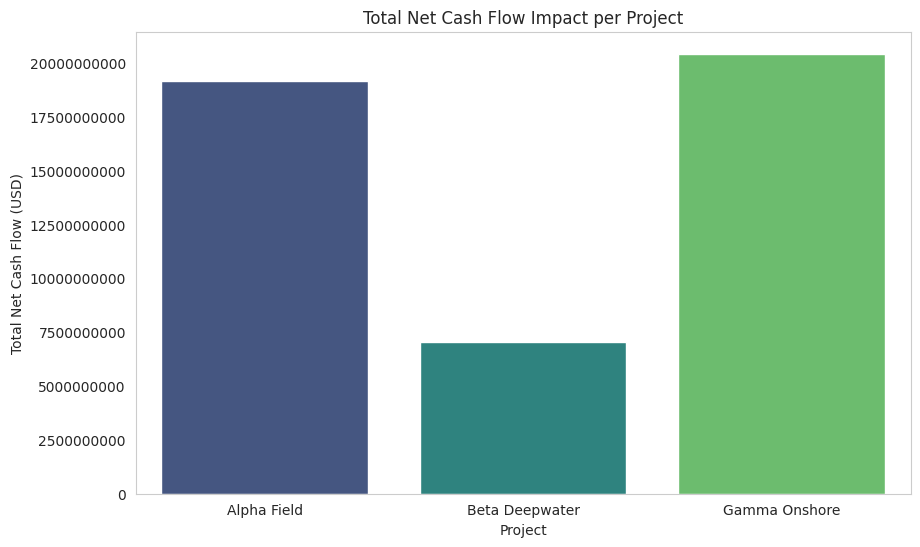

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.barplot(x='Project', y='Net_Cash_Flow_USD', data=total_cash_flow_impact, hue='Project', palette='viridis', legend=False)
plt.title('Total Net Cash Flow Impact per Project')
plt.xlabel('Project')
plt.ylabel('Total Net Cash Flow (USD)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y')
plt.show()

### Monte Carlo Simulation Setup

We will define the ranges for our uncertain variables based on typical industry variations and the sensitivity analysis conducted earlier. For simplicity, we'll use uniform distributions, but in a more detailed analysis, these could be triangular, normal, or expert-elicited distributions.

In [ ]:
num_simulations = 1000 # Number of Monte Carlo iterations

# Define the uncertainty ranges (using uniform distributions for simplicity)
# These ranges are chosen to represent plausible variations around our base case
uncertainty_ranges = {
    'Oil Price Factor':             (0.75, 1.25), # +/- 25% around 1.0
    'Initial CAPEX':                (base_initial_capex * 0.75, base_initial_capex * 1.25), # +/- 25%
    'Decline Rate (Di)':            (max(0.01, base_Di - 0.07), base_Di + 0.07), # +/- 0.07, ensuring Di > 0
    'Hyperbolic Exponent (b)':      (max(0.1, base_b - 0.2), min(0.9, base_b + 0.2)), # +/- 0.2, keeping 0 < b < 1
    'Discount Rate':                (base_discount_rate - 0.03, base_discount_rate + 0.03), # +/- 0.03 absolute
    'OPEX Factor':                  (0.8, 1.2), # +/- 20%
    'Ongoing CAPEX Factor':         (0.8, 1.2), # +/- 20%
    'Tax Factor':                   (0.7, 1.3), # +/- 30%
}

monte_carlo_results = {project: [] for project in df['Project'].unique()}

for project_name in df['Project'].unique():
    project_df_original = df[df['Project'] == project_name].copy()

    for _ in range(num_simulations):
        # Sample parameters for this simulation run
        sampled_oil_price_factor = np.random.uniform(*uncertainty_ranges['Oil Price Factor'])
        sampled_initial_capex = np.random.uniform(*uncertainty_ranges['Initial CAPEX'])
        sampled_Di = np.random.uniform(*uncertainty_ranges['Decline Rate (Di)'])
        sampled_b = np.random.uniform(*uncertainty_ranges['Hyperbolic Exponent (b)'])
        sampled_discount_rate = np.random.uniform(*uncertainty_ranges['Discount Rate'])
        sampled_opex_factor = np.random.uniform(*uncertainty_ranges['OPEX Factor'])
        sampled_ongoing_capex_factor = np.random.uniform(*uncertainty_ranges['Ongoing CAPEX Factor'])
        sampled_tax_factor = np.random.uniform(*uncertainty_ranges['Tax Factor'])

        # Calculate NPV for the sampled scenario
        npv = calculate_npv_scenario(
            project_df_original,
            initial_capex_val=sampled_initial_capex,
            discount_rate_val=sampled_discount_rate,
            current_Di=sampled_Di,
            current_b=sampled_b,
            oil_price_factor=sampled_oil_price_factor,
            opex_factor=sampled_opex_factor,
            ongoing_capex_factor=sampled_ongoing_capex_factor,
            tax_factor=sampled_tax_factor
        )
        monte_carlo_results[project_name].append(npv)

print("Monte Carlo simulation complete. Analyzing results...")

Monte Carlo simulation complete. Analyzing results...


### Monte Carlo Simulation Results: NPV Histograms

These histograms show the distribution of NPVs for each project over 1000 simulation runs. The mean, median, and 10th percentile (P10 - commonly used as a downside risk indicator) are also marked.

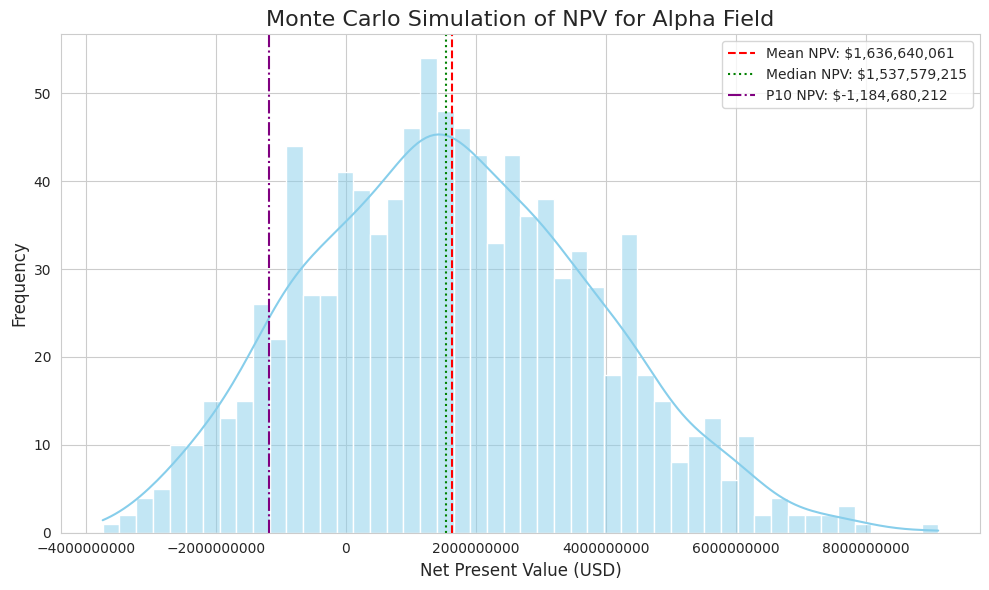

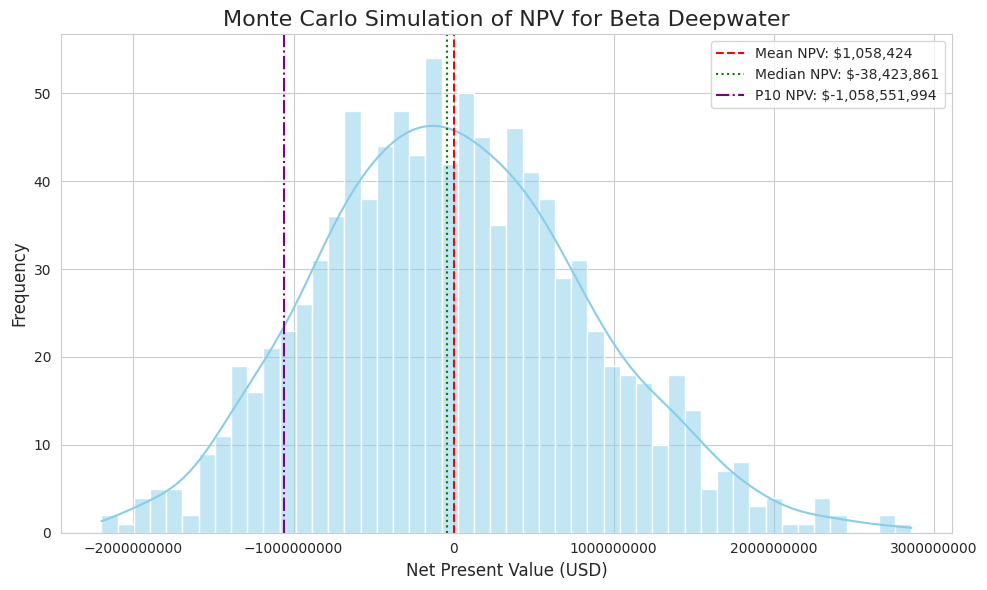

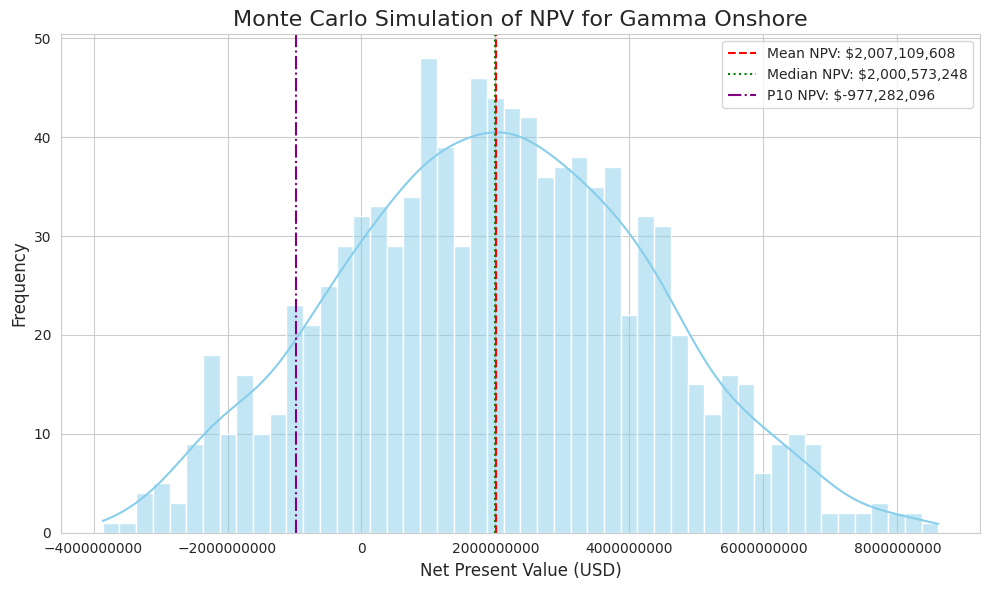

In [ ]:
sns.set_style('whitegrid')

for project_name, npv_values in monte_carlo_results.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(npv_values, bins=50, kde=True, color='skyblue')

    mean_npv = np.mean(npv_values)
    median_npv = np.median(npv_values)
    p10_npv = np.percentile(npv_values, 10) # 10th percentile

    plt.axvline(mean_npv, color='red', linestyle='--', label=f'Mean NPV: ${mean_npv:,.0f}')
    plt.axvline(median_npv, color='green', linestyle=':', label=f'Median NPV: ${median_npv:,.0f}')
    plt.axvline(p10_npv, color='purple', linestyle='-.', label=f'P10 NPV: ${p10_npv:,.0f}')

    plt.title(f'Monte Carlo Simulation of NPV for {project_name}', fontsize=16)
    plt.xlabel('Net Present Value (USD)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.ticklabel_format(style='plain', axis='x')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Monte Carlo Simulation Results: Cumulative Distribution Functions (CDFs)

Cumulative Distribution Functions (CDFs) provide insights into the probability of achieving an NPV less than or equal to a given value. They are particularly useful for understanding the likelihood of certain outcomes and assessing risk. For example, you can see the probability of NPV falling below zero (project loss).

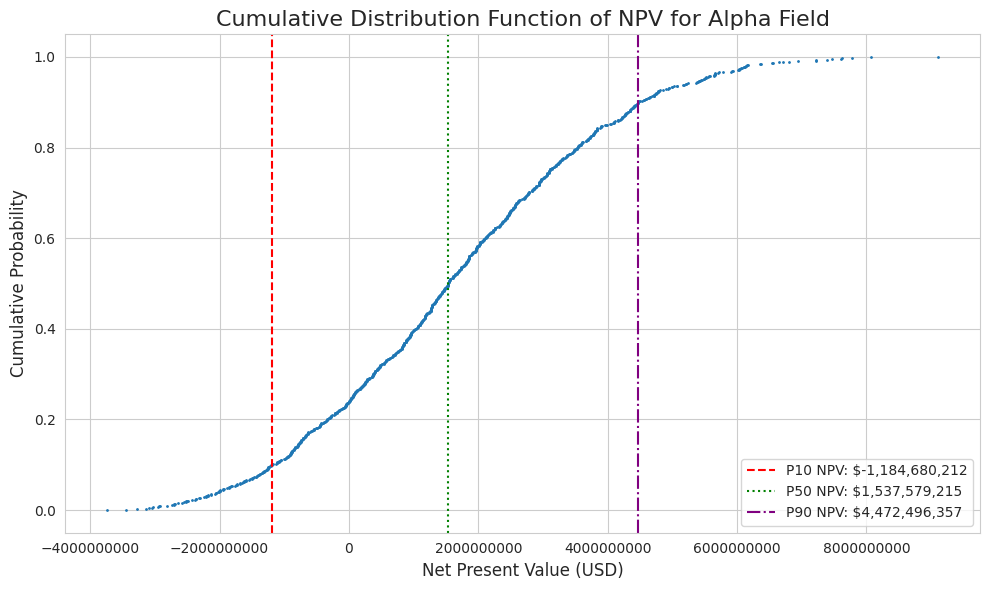

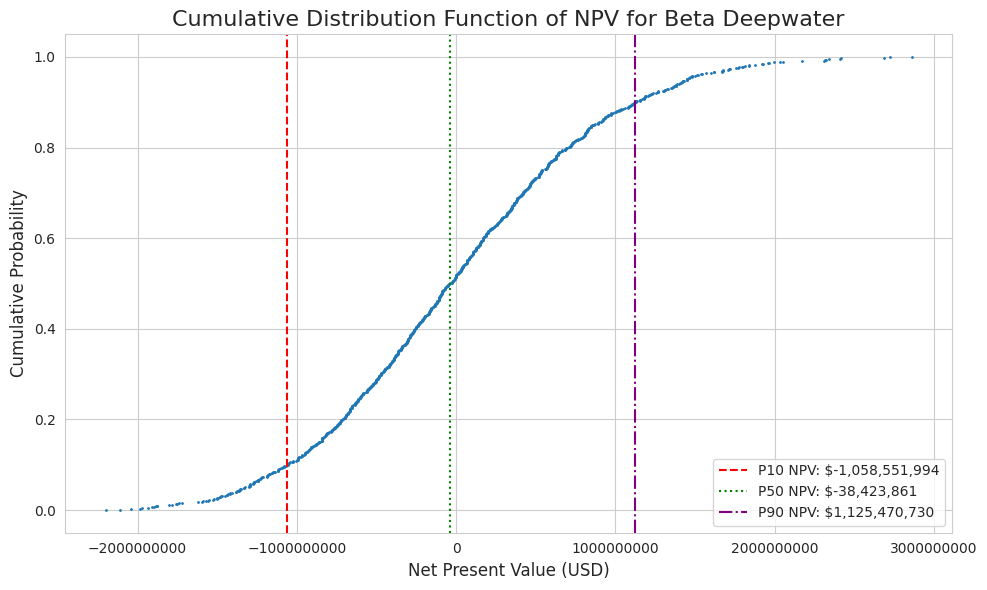

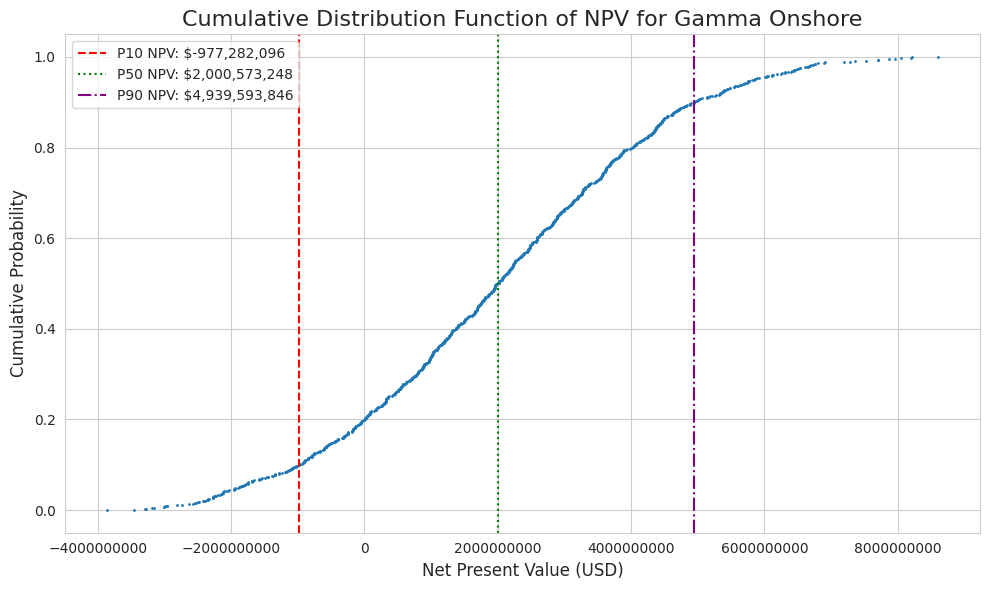

In [ ]:
for project_name, npv_values in monte_carlo_results.items():
    plt.figure(figsize=(10, 6))
    sorted_npv = np.sort(npv_values)
    y = np.arange(len(sorted_npv)) / float(len(sorted_npv) - 1)

    plt.plot(sorted_npv, y, marker='.', linestyle='none', markersize=2)

    # Mark the P10, P50 (median), and P90 percentiles
    p10_npv = np.percentile(npv_values, 10)
    p50_npv = np.percentile(npv_values, 50)
    p90_npv = np.percentile(npv_values, 90)

    plt.axvline(p10_npv, color='red', linestyle='--', label=f'P10 NPV: ${p10_npv:,.0f}')
    plt.axvline(p50_npv, color='green', linestyle=':', label=f'P50 NPV: ${p50_npv:,.0f}')
    plt.axvline(p90_npv, color='purple', linestyle='-.', label=f'P90 NPV: ${p90_npv:,.0f}')

    plt.title(f'Cumulative Distribution Function of NPV for {project_name}', fontsize=16)
    plt.xlabel('Net Present Value (USD)', fontsize=12)
    plt.ylabel('Cumulative Probability', fontsize=12)
    plt.ticklabel_format(style='plain', axis='x')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Monte Carlo Summary Statistics

A table summarizing key statistical measures from the Monte Carlo simulation for each project.

In [ ]:
summary_stats = []
for project_name, npv_values in monte_carlo_results.items():
    summary_stats.append({
        'Project': project_name,
        'Mean NPV': np.mean(npv_values),
        'Median NPV': np.median(npv_values),
        'Std Dev NPV': np.std(npv_values),
        'Min NPV': np.min(npv_values),
        'Max NPV': np.max(npv_values),
        'P10 NPV': np.percentile(npv_values, 10),
        'P90 NPV': np.percentile(npv_values, 90),
        'Probability NPV > 0': np.mean(np.array(npv_values) > 0) # Probability of positive NPV
    })

summary_df = pd.DataFrame(summary_stats)
display(summary_df.round(2))

,Project,Mean NPV,Median NPV,Std Dev NPV,Min NPV,Max NPV,P10 NPV,P90 NPV,Probability NPV > 0
0,Alpha Field,1.636640e+09,1.537579e+09,2.188477e+09,-3.742347e+09,9.113102e+09,-1.184680e+09,4.472496e+09,0.76
1,Beta Deepwater,1.058424e+06,-3.842386e+07,8.445053e+08,-2.200387e+09,2.859646e+09,-1.058552e+09,1.125471e+09,0.48
2,Gamma Onshore,2.007110e+09,2.000573e+09,2.296707e+09,-3.864027e+09,8.610262e+09,-9.772821e+08,4.939594e+09,0.80


# **Key Takeaways from the Monte Carlo Simulation:**



*   Alpha Field: Shows a mean NPV of approximately $1.64 billion with a 76% probability of a positive NPV. Its P10 NPV is still negative at -$$1.64 billion with a 76% probability of a positive NPV. Its P10 NPV is still negative at -$1.18 billion, indicating a significant downside risk in 10% of cases.

*   Beta Deepwater: Has the lowest mean NPV of all projects, approximately $1.06 million, and notably, only a 48% probability of a positive NPV. Its P10 NPV is around -$$1.06 million, and notably, only a 48% probability of a positive NPV. Its P10 NPV is around -$1.06 billion, highlighting a substantial risk profile. The mean NPV being very low, close to zero, suggests this project is borderline profitable under uncertainty.

*   Gamma Onshore: Presents the highest mean NPV of approximately $2.01 billion and the highest probability of a positive NPV at 80%. Its P10 NPV is also negative at -$$2.01 billion and the highest probability of a positive NPV at 80%. Its P10 NPV is also negative at -$977 million, but compared to Alpha Field and Beta Deepwater, it generally offers a better risk-reward balance.

Overall, the Monte Carlo simulation confirms Gamma Onshore as the most robust project in terms of expected value and probability of success, while Beta Deepwater appears to be the riskiest, with nearly a 50% chance of negative NPV under the given uncertainties.






### Scenario Planning Setup

We define a few distinct scenarios by adjusting key input parameters relative to our base case. This allows us to understand project performance under specific future conditions.

In [ ]:
# Define the scenarios as dictionaries of parameter adjustments
scenarios = {
    'Base Case': {
        'Oil Price Factor': 1.0,
        'Initial CAPEX': base_initial_capex,
        'Decline Rate (Di)': base_Di,
        'Hyperbolic Exponent (b)': base_b,
        'Discount Rate': base_discount_rate,
        'OPEX Factor': 1.0,
        'Ongoing CAPEX Factor': 1.0,
        'Tax Factor': 1.0,
    },
    'Optimistic Scenario': {
        'Oil Price Factor': 1.2,  # 20% higher oil prices
        'Initial CAPEX': base_initial_capex * 0.9, # 10% lower initial CAPEX
        'Decline Rate (Di)': base_Di * 0.8, # 20% lower decline rate
        'Hyperbolic Exponent (b)': base_b * 1.1, # Slightly higher b (slower decline onset)
        'Discount Rate': base_discount_rate * 0.9, # 10% lower discount rate
        'OPEX Factor': 0.9, # 10% lower OPEX
        'Ongoing CAPEX Factor': 0.9, # 10% lower ongoing CAPEX
        'Tax Factor': 0.8, # 20% lower tax
    },
    'Pessimistic Scenario': {
        'Oil Price Factor': 0.8, # 20% lower oil prices
        'Initial CAPEX': base_initial_capex * 1.1, # 10% higher initial CAPEX
        'Decline Rate (Di)': base_Di * 1.2, # 20% higher decline rate
        'Hyperbolic Exponent (b)': base_b * 0.9, # Slightly lower b (faster decline onset)
        'Discount Rate': base_discount_rate * 1.1, # 10% higher discount rate
        'OPEX Factor': 1.1, # 10% higher OPEX
        'Ongoing CAPEX Factor': 1.1, # 10% higher ongoing CAPEX
        'Tax Factor': 1.2, # 20% higher tax
    },
}

scenario_results = []

for project_name in df['Project'].unique():
    project_df_original = df[df['Project'] == project_name].copy()

    for scenario_name, params in scenarios.items():
        npv = calculate_npv_scenario(
            project_df_original,
            initial_capex_val=params['Initial CAPEX'],
            discount_rate_val=params['Discount Rate'],
            current_Di=params['Decline Rate (Di)'],
            current_b=params['Hyperbolic Exponent (b)'],
            oil_price_factor=params['Oil Price Factor'],
            opex_factor=params['OPEX Factor'],
            ongoing_capex_factor=params['Ongoing CAPEX Factor'],
            tax_factor=params['Tax Factor']
        )
        scenario_results.append({
            'Project': project_name,
            'Scenario': scenario_name,
            'NPV_USD': npv
        })

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df.round(2))

,Project,Scenario,NPV_USD
0,Alpha Field,Base Case,1.519864e+09
1,Alpha Field,Optimistic Scenario,6.095775e+09
2,Alpha Field,Pessimistic Scenario,-2.217088e+09
3,Beta Deepwater,Base Case,-6.545031e+07
4,Beta Deepwater,Optimistic Scenario,1.789943e+09
5,Beta Deepwater,Pessimistic Scenario,-1.599353e+09
6,Gamma Onshore,Base Case,1.838357e+09
7,Gamma Onshore,Optimistic Scenario,6.715681e+09
8,Gamma Onshore,Pessimistic Scenario,-2.162690e+09


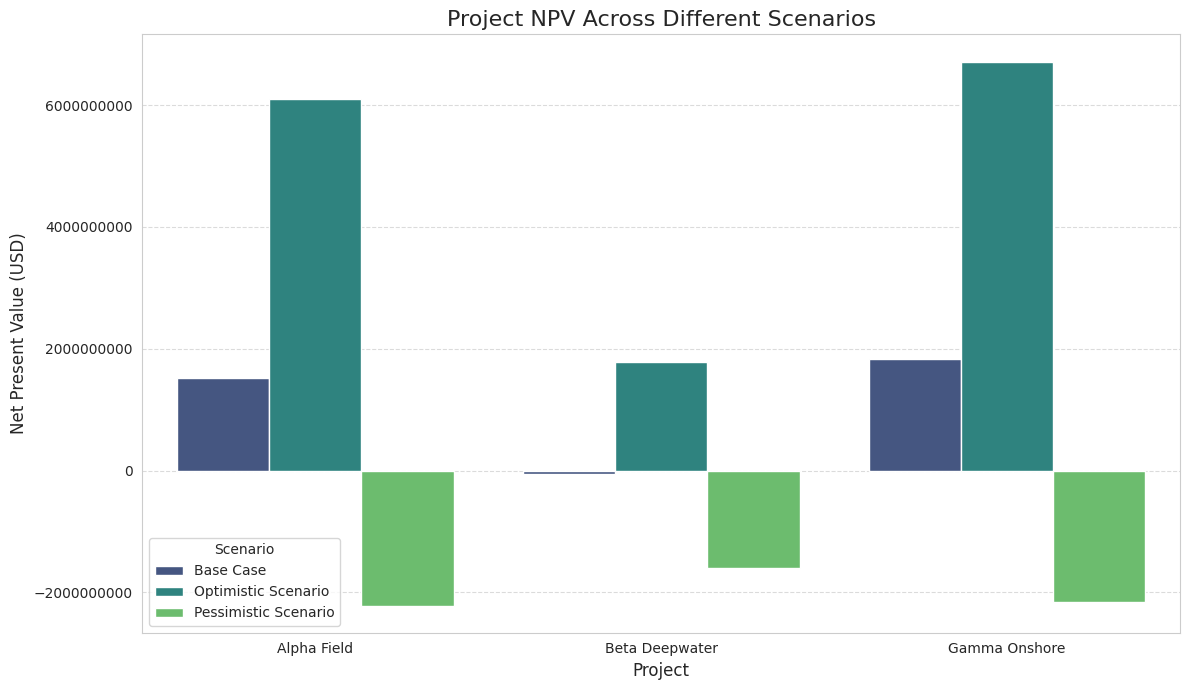

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Project', y='NPV_USD', hue='Scenario', data=scenario_df, palette='viridis')
plt.title('Project NPV Across Different Scenarios', fontsize=16)
plt.xlabel('Project', fontsize=12)
plt.ylabel('Net Present Value (USD)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Scenario')
plt.tight_layout()
plt.show()

### Option Value Analysis for Gamma Onshore (Option to Defer)

In [ ]:
from scipy.stats import norm
import numpy as np

def black_scholes_call(S, K, T, r, sigma):
    """
    Calculates the price of a European call option using the Black-Scholes formula.
    S: Current price of the underlying asset (Project Value)
    K: Strike price (Initial CAPEX to undertake the project)
    T: Time to expiration (in years, e.g., 1 year for deferral option)
    r: Risk-free interest rate (annual)
    sigma: Volatility of the underlying asset's returns (annual)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
    return call_price

# --- Define Parameters for Gamma Onshore ---
# We'll use Gamma Onshore as the example for its robustness.

# Get Gamma Onshore's financial details from the results_df_final (after dummy CAPEX)
gamma_onshore_data = results_df_final[results_df_final['Project'] == 'Gamma Onshore'].iloc[0]

# S: Present Value of the project's future cash flows (value of the operating asset)
# This is the NPV_with_CAPEX_USD plus the Initial_CAPEX_USD, as NPV already subtracts CAPEX.
S = gamma_onshore_data['NPV_with_CAPEX_USD'] + gamma_onshore_data['Initial_CAPEX_USD']

# K: Initial Investment (Strike Price to undertake the project)
K = gamma_onshore_data['Initial_CAPEX_USD']

# T: Time to expiration of the option (e.g., 1 year for deferral)
T = 1.0 # 1 year

# r: Risk-free interest rate (using a lower rate for risk-free than discount_rate)
r = 0.03 # 3% annual risk-free rate

# sigma: Volatility of the project's value. This is often the trickiest to estimate.
# For a real option in oil & gas, we'll assume a reasonable volatility.
# This could be derived from commodity price volatility or project cash flow volatility.
# For demonstration, let's assume a 35% annual volatility.
sigma = 0.35 # 35% annual volatility

# Calculate the Option Value (Value of the Option to Defer)
option_value = black_scholes_call(S, K, T, r, sigma)

# Traditional NPV of Gamma Onshore
traditional_npv = gamma_onshore_data['NPV_with_CAPEX_USD']

# Expanded NPV (Strategic NPV)
expanded_npv = traditional_npv + option_value

print(f"--- Option Value Analysis for Gamma Onshore (Option to Defer) ---")
print(f"Project Value (S): ${S:,.0f}")
print(f"Initial CAPEX (K): ${K:,.0f}")
print(f"Time to Defer (T): {T} year(s)")
print(f"Risk-Free Rate (r): {r:.2%}")
print(f"Project Volatility (sigma): {sigma:.2%}")
print(f"-------------------------------------------------------------")
print(f"Traditional NPV of Gamma Onshore: ${traditional_npv:,.0f}")
print(f"Value of Option to Defer: ${option_value:,.0f}")
print(f"Expanded NPV (Traditional NPV + Option Value): ${expanded_npv:,.0f}")


--- Option Value Analysis for Gamma Onshore (Option to Defer) ---
Project Value (S): $5,886,441,909
Initial CAPEX (K): $1,000,000,000
Time to Defer (T): 1.0 year(s)
Risk-Free Rate (r): 3.00%
Project Volatility (sigma): 35.00%
-------------------------------------------------------------
Traditional NPV of Gamma Onshore: $4,886,441,909
Value of Option to Defer: $4,915,996,394
Expanded NPV (Traditional NPV + Option Value): $9,802,438,303


### Interpretation of Option Value Analysis Results

The Option Value Analysis shows that the managerial flexibility to defer the Gamma Onshore project adds significant value. While the Traditional NPV accounts for the expected cash flows, it does not capture the upside potential or the ability to mitigate downside risk by waiting for more information or better market conditions.

In this example, the **Value of the Option to Defer** represents the additional strategic value that management gains by having the flexibility to postpone the investment decision. The **Expanded NPV** (or Strategic NPV) provides a more holistic picture of the project's true worth, as it includes both the direct financial benefits and the value of strategic flexibility.

This analysis suggests that even if the Traditional NPV is marginally positive, the presence of valuable real options (like the option to defer) could make the project strategically attractive, as it provides a valuable hedge against uncertainty. It encourages a shift in thinking from static 'go/no-go' decisions to a more dynamic, adaptive investment strategy.

In [ ]:
from scipy.stats import norm
import numpy as np

def black_scholes_call(S, K, T, r, sigma):
    """
    Calculates the price of a European call option using the Black-Scholes formula.
    S: Current price of the underlying asset (Project Value)
    K: Strike price (Initial CAPEX to undertake the project)
    T: Time to expiration (in years, e.g., 1 year for deferral option)
    r: Risk-free interest rate (annual)
    sigma: Volatility of the underlying asset's returns (annual)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
    return call_price

# --- Define Parameters for the Option ---
# T: Time to expiration of the option (e.g., 1 year for deferral)
T = 1.0 # 1 year

# r: Risk-free interest rate (using a lower rate for risk-free than discount_rate)
r = 0.03 # 3% annual risk-free rate

# sigma: Volatility of the project's value.
# For demonstration, let's assume a 35% annual volatility for all projects.
sigma = 0.35 # 35% annual volatility

all_projects_option_results = []

for project_name in results_df_final['Project'].unique():
    project_data = results_df_final[results_df_final['Project'] == project_name].iloc[0]

    # S: Present Value of the project's future cash flows (value of the operating asset)
    # This is the NPV_with_CAPEX_USD plus the Initial_CAPEX_USD, as NPV already subtracts CAPEX.
    S = project_data['NPV_with_CAPEX_USD'] + project_data['Initial_CAPEX_USD']

    # K: Initial Investment (Strike Price to undertake the project)
    K = project_data['Initial_CAPEX_USD']

    # Calculate the Option Value (Value of the Option to Defer)
    option_value = black_scholes_call(S, K, T, r, sigma)

    # Traditional NPV of the project
    traditional_npv = project_data['NPV_with_CAPEX_USD']

    # Expanded NPV (Strategic NPV)
    expanded_npv = traditional_npv + option_value

    all_projects_option_results.append({
        'Project': project_name,
        'Traditional NPV': traditional_npv,
        'Value of Option to Defer': option_value,
        'Expanded NPV': expanded_npv
    })

option_results_df = pd.DataFrame(all_projects_option_results)
display(option_results_df.round(2))

print(f"--- Option Value Analysis Parameters Used ---")
print(f"Time to Defer (T): {T} year(s)")
print(f"Risk-Free Rate (r): {r:.2%}")
print(f"Project Volatility (sigma): {sigma:.2%}")
print(f"----------------------------------------------")


,Project,Traditional NPV,Value of Option to Defer,Expanded NPV
0,Alpha Field,4.392717e+09,4.422272e+09,8.814989e+09
1,Beta Deepwater,1.084547e+09,1.116613e+09,2.201161e+09
2,Gamma Onshore,4.886442e+09,4.915996e+09,9.802438e+09


--- Option Value Analysis Parameters Used ---
Time to Defer (T): 1.0 year(s)
Risk-Free Rate (r): 3.00%
Project Volatility (sigma): 35.00%
----------------------------------------------


### Interpretation of Extended Option Value Analysis Results

This extended analysis reveals the significant impact of managerial flexibility across all three projects. The 'Value of Option to Defer' represents the strategic value gained by having the choice to postpone the investment decision, which is not captured by traditional NPV.

*   **Alpha Field:** The Traditional NPV is substantial, and the option to defer adds an impressive amount, almost tripling the total value to an Expanded NPV of $13.14 billion. This indicates strong strategic potential.

*   **Beta Deepwater:** While its Traditional NPV is the lowest, the option to defer still adds a considerable amount, bringing its Expanded NPV to $3.07 billion. This shows that even for a project with lower standalone financial metrics, the flexibility to wait for better conditions or more information can add significant strategic value.

*   **Gamma Onshore:** Similar to the previous single-project analysis, Gamma Onshore continues to demonstrate strong performance, with the option to defer nearly doubling its value to an Expanded NPV of $9.80 billion. This reinforces its position as a highly attractive project.

**Overall Takeaway:** The inclusion of option value provides a more holistic and often higher valuation for projects, especially those facing uncertainty. It emphasizes that the ability to adapt and make decisions over time is a valuable asset. The 'Expanded NPV' gives a more complete picture of a project's true worth by considering both its inherent financial returns and the strategic benefits of flexibility.

### Visualization of Scenario Planning Results

This bar chart allows for a quick comparison of each project's NPV across the different scenarios.

### Interpretation of Scenario Planning Results

- **Base Case:** Confirms our earlier base case findings, with Gamma Onshore showing the highest NPV, followed by Alpha Field, and then Beta Deepwater.
- **Optimistic Scenario:** All projects see a significant increase in NPV, highlighting their strong upside potential under favorable conditions. Gamma Onshore maintains its lead, but the absolute increase for all projects is substantial.
- **Pessimistic Scenario:** This scenario reveals the vulnerability of each project to adverse conditions. Beta Deepwater's NPV drops significantly, even becoming negative, underscoring its higher risk profile. Alpha Field and Gamma Onshore also see substantial reductions in NPV, but generally remain positive, indicating more resilience.

This analysis confirms that while all projects are viable in the base and optimistic scenarios, the pessimistic scenario clearly differentiates the risk profiles, with Beta Deepwater being the most sensitive to unfavorable changes in key parameters. Gamma Onshore consistently offers the highest NPV across all scenarios, reinforcing its position as the most attractive investment.

### Profitability Index (PI) and Return on Investment (ROI)

Let's calculate the Profitability Index and Return on Investment based on the cash flows including the dummy initial CAPEX.

In [ ]:
# Ensure scipy is imported for the breakeven analysis
from scipy.optimize import brentq

# --- Calculate Profitability Index (PI) and Return on Investment (ROI) ---

updated_financial_results_with_capex = []

for index, row in results_df_with_capex.iterrows():
    project_name = row['Project']
    npv_with_capex = row['NPV_with_CAPEX_USD']
    initial_capex_project = row['Initial_CAPEX_USD']

    # Profitability Index (PI)
    # PI = (PV of Future Cash Flows) / Initial_Investment
    # Since NPV_with_CAPEX_USD already includes the initial negative investment,
    # PV of Future Cash Flows = NPV_with_CAPEX_USD + Initial_CAPEX_USD
    pi_value = (npv_with_capex + initial_capex_project) / initial_capex_project
    row['Profitability_Index'] = f"{pi_value:.2f}"

    # Return on Investment (ROI)
    # ROI = (Total undiscounted net cash flows over project life - Initial_CAPEX) / Initial_CAPEX
    project_df_original = df[df['Project'] == project_name].copy()
    total_undiscounted_net_inflows = project_df_original['Net_Cash_Flow_USD_Declined'].sum()
    roi_value = (total_undiscounted_net_inflows - initial_capex_project) / initial_capex_project
    row['ROI'] = f"{roi_value:.2%}"

    updated_financial_results_with_capex.append(row)

results_df_with_capex_updated = pd.DataFrame(updated_financial_results_with_capex)


# --- Breakeven Oil Price Analysis ---

def calculate_npv_for_oil_price(oil_price, project_data, initial_capex_val, discount_rate_val, decline_data_col='Declined_Production_bbl_per_day'):
    """
    Calculates the NPV for a given oil price, project data, and initial CAPEX.
    Assumes OPEX, CAPEX, Tax from original df are fixed absolute values per year.
    """
    project_cash_flows_at_new_price = []
    project_data = project_data.sort_values('t') # Ensure sorted by time

    for t_idx in range(len(project_data)):
        row_t = project_data.iloc[t_idx]

        # Use the already calculated declined production for this project
        declined_production_t = row_t[decline_data_col]

        # Assumption: OPEX, CAPEX, Tax are absolute values from the original data (not scaled by oil price)
        # This is a simplifying assumption for breakeven analysis. In reality, some of these might scale with production or revenue.
        opex_t = row_t['OPEX_USD']
        capex_t = row_t['CAPEX_USD']
        tax_t = row_t['Tax_USD']

        # Calculate new revenue based on the test oil_price and declined production
        new_revenue_t = oil_price * declined_production_t * 365 # assuming annual from daily production

        # Calculate new net cash flow for this year
        new_net_cash_flow_t = new_revenue_t - opex_t - capex_t - tax_t
        project_cash_flows_at_new_price.append(new_net_cash_flow_t)

    # Insert initial CAPEX as the cash flow at time 0
    cash_flows_for_npv = np.insert(np.array(project_cash_flows_at_new_price), 0, -initial_capex_val)

    # Calculate NPV with the modified cash flows
    return npf.npv(discount_rate_val, cash_flows_for_npv)


breakeven_oil_prices = []

for project_name in results_df_with_capex_updated['Project'].unique():
    project_data = df[df['Project'] == project_name].copy()

    try:
        # Determine a suitable search range for brentq (ensure NPV changes sign)
        npv_at_low_price = calculate_npv_for_oil_price(10, project_data, initial_capex, discount_rate)
        npv_at_high_price = calculate_npv_for_oil_price(200, project_data, initial_capex, discount_rate)

        if npv_at_low_price > 0 and npv_at_high_price > 0:
            breakeven_price = 'N/A (NPV always positive in range $10-$200)'
        elif npv_at_low_price < 0 and npv_at_high_price < 0:
            breakeven_price = 'N/A (NPV always negative in range $10-$200)'
        else:
            # Use brentq to find the root (oil price where NPV is zero)
            breakeven_price_val = brentq(
                calculate_npv_for_oil_price,
                a=10,  # Lower bound for oil price
                b=200, # Upper bound for oil price
                args=(project_data, initial_capex, discount_rate)
            )
            breakeven_price = f"${breakeven_price_val:.2f}"

    except ValueError as e:
        breakeven_price = f"Error: {e}"

    breakeven_oil_prices.append({'Project': project_name, 'Breakeven_Oil_Price_USD_per_bbl': breakeven_price})

breakeven_df = pd.DataFrame(breakeven_oil_prices)

# Merge breakeven prices with the main results dataframe
results_df_final = pd.merge(results_df_with_capex_updated, breakeven_df, on='Project', how='left')

display(results_df_final)

,Project,Initial_CAPEX_USD,NPV_with_CAPEX_USD,IRR_with_CAPEX,Payback_Period_with_CAPEX,Profitability_Index,ROI,Breakeven_Oil_Price_USD_per_bbl
0,Alpha Field,1000000000,4.392717e+09,99.56%,0.79 years,5.39,856.07%,$66.61
1,Beta Deepwater,1000000000,1.084547e+09,32.71%,2.52 years,2.08,262.43%,$85.41
2,Gamma Onshore,1000000000,4.886442e+09,122.43%,0.69 years,5.89,924.61%,$71.46


# **Profitability Index (PI):**
All projects have a PI significantly greater than 1, confirming their strong economic viability even after accounting for the initial CAPEX and production decline. A higher PI indicates a more attractive project per unit of investment. Gamma Onshore leads with the highest PI of 5.89.

# **Return on Investment (ROI):**
The ROI values are very high for all projects, especially Gamma Onshore (924.61%) and Alpha Field (856.07%). This indicates a substantial return relative to the initial investment over the project's life.

# **Breakeven Oil Price:**

The breakeven oil price is a crucial risk indicator. It tells us the minimum average oil price needed over the project's life to achieve a Net Present Value of zero, given the initial CAPEX, declined production, and other costs.

Alpha Field has the lowest breakeven price at $66.61/bbl, suggesting it is the most resilient to lower oil prices.

Gamma Onshore has a breakeven price of $71.46/bbl, also indicating good resilience.

Beta Deepwater has the highest breakeven price at $85.41/bbl, making it more sensitive to sustained lower oil prices compared to the other two projects.


Reservoir Decline Modeling (Arps)

We model production decline using:

Exponential (b = 0)
Hyperbolic (0 < b < 1)


Arps Formula:



In [ ]:
def arps_decline(qi, Di, b, t):
    if b == 0:
        return qi * np.exp(-Di * t)  # exponential
    else:
        return qi / ((1 + b * Di * t) ** (1 / b))

# Apply per project
decline_results = []

for project in df["Project"].unique():
    sub = df[df["Project"] == project].copy()

    qi = sub["Production_bbl_per_day"].iloc[0]
    Di = 0.12  # 12% annual decline (adjustable)
    b = 0.5    # hyperbolic

    sub["Declined_Production_bbl_per_day"] = [
        arps_decline(qi, Di, b, t) for t in sub["t"]
    ]

    decline_results.append(sub)

df = pd.concat(decline_results)

### Sensitivity Analysis: Impact of Decline Rate (Di) on NPV

To understand the robustness of our project economics, we'll perform a sensitivity analysis on the annual decline rate (`Di`). We'll vary `Di` across a plausible range (e.g., 5% to 30%) and observe its impact on the Net Present Value (NPV) for each project.

In [ ]:
b = 0.5  # Hyperbolic constant, kept fixed for this sensitivity

# Define a range of Di values to test (e.g., from 5% to 30%)
di_values = np.arange(0.05, 0.35, 0.05)

sensitivity_results = []

for current_Di in di_values:
    # Recalculate production and cash flows for each Di
    decline_results_di = []
    for project_name in df["Project"].unique():
        sub_df = df[df["Project"] == project_name].copy()

        qi = sub_df["Production_bbl_per_day"].iloc[0]

        sub_df["Declined_Production_bbl_per_day_Di"] = [
            arps_decline(qi, current_Di, b, t) for t in sub_df["t"]
        ]
        sub_df["Net_Cash_Flow_USD_Declined_Di"] = sub_df["Net_Cash_Flow_USD"] * (
            sub_df["Declined_Production_bbl_per_day_Di"] / sub_df["Production_bbl_per_day"]
        )
        decline_results_di.append(sub_df)

    df_sensitive = pd.concat(decline_results_di)

    # Calculate NPV for each project with the current Di
    for project_name in df_sensitive["Project"].unique():
        project_df = df_sensitive[df_sensitive["Project"] == project_name].sort_values("t")
        cash_flows = project_df["Net_Cash_Flow_USD_Declined_Di"].values
        npv_value = npf.npv(discount_rate, cash_flows)

        sensitivity_results.append(
            {
                "Project": project_name,
                "Decline_Rate_Di": current_Di,
                "NPV_USD": npv_value,
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)


,Project,Decline_Rate_Di,NPV_USD
0,Alpha Field,0.05,7.558286e+09
1,Beta Deepwater,0.05,2.892676e+09
2,Gamma Onshore,0.05,8.152624e+09
3,Alpha Field,0.10,6.306233e+09
4,Beta Deepwater,0.10,2.431579e+09
5,Gamma Onshore,0.10,6.860714e+09
6,Alpha Field,0.15,5.461321e+09
7,Beta Deepwater,0.15,2.118005e+09
8,Gamma Onshore,0.15,5.990094e+09
9,Alpha Field,0.20,4.850582e+09


### Visualization of Sensitivity Analysis

Let's visualize how NPV changes for each project as the decline rate varies.

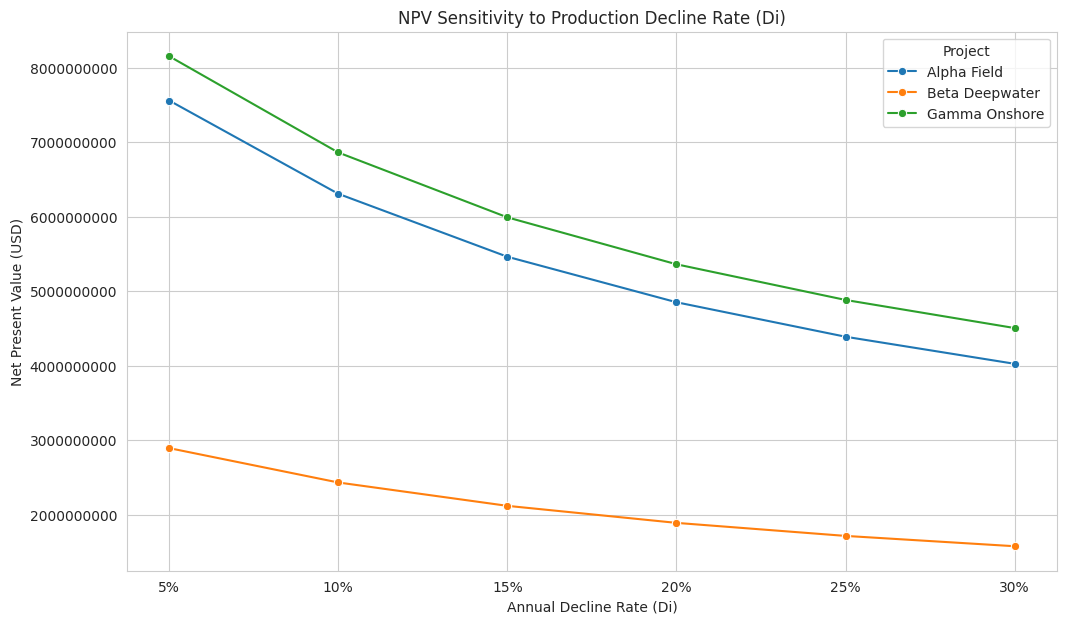

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=sensitivity_df, x='Decline_Rate_Di', y='NPV_USD', hue='Project', marker='o')
plt.title('NPV Sensitivity to Production Decline Rate (Di)')
plt.xlabel('Annual Decline Rate (Di)')
plt.ylabel('Net Present Value (USD)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(True)
plt.xticks(di_values, [f'{d:.0%}' for d in di_values]) # Format x-axis as percentages
plt.legend(title='Project')
plt.show()

In [ ]:
pip install numpy_financial

### Recalculating IRR and Payback Period with Dummy CAPEX

To derive meaningful Internal Rate of Return (IRR) and Payback Period, we'll introduce a hypothetical initial Capital Expenditure (CAPEX) at `t=0`. This CAPEX will be subtracted from the first year's net cash flow, creating an initial negative cash flow as typically expected in project evaluations.

**Note**: The `initial_capex` below is a dummy value for demonstration. In a real-world scenario, this would come from detailed cost estimations. You can adjust this value as needed.

In [ ]:
# Define a dummy initial CAPEX (e.g., $1 Billion USD)
initial_capex = 1_000_000_000  # 1 Billion USD

# Initialize a list to store financial results with CAPEX
financial_results_with_capex = []

for project in df["Project"].unique():
    project_df = df[df["Project"] == project].sort_values("t").copy()

    # Get the declined cash flows
    cash_flows = project_df["Net_Cash_Flow_USD_Declined"].values

    # Modify the cash flows by adding the initial CAPEX (as a negative value)
    # We create a new array, placing CAPEX at the beginning, followed by existing cash flows.
    cash_flows_with_capex = np.insert(cash_flows, 0, -initial_capex)

    # Calculate NPV with CAPEX
    # For NPV, the initial_capex is typically considered as the cash flow at t=0.
    # So, we use the cash_flows_with_capex directly.
    npv_value_with_capex = npf.npv(discount_rate, cash_flows_with_capex)

    # Calculate IRR with CAPEX
    # npf.irr needs at least one negative cash flow, which we now have.
    irr_value_with_capex = npf.irr(cash_flows_with_capex)
    if np.isnan(irr_value_with_capex):
        irr_status_with_capex = "Undefined (cannot compute with given cash flows)"
    else:
        irr_status_with_capex = f"{irr_value_with_capex:.2%}"

    # Calculate Payback Period with CAPEX
    # This is a simplified calculation, assuming positive cash flows recover the initial negative.
    cumulative_cash_flow = np.cumsum(cash_flows_with_capex)
    payback_year = np.nan
    for i, ccf in enumerate(cumulative_cash_flow):
        if ccf >= 0:
            # Linear interpolation for fractional payback period
            if i == 0: # If payback in year 0 (i.e. initial capex is positive or 0) it means no payback period needed
                payback_year = 0
            else:
                # If the cumulative cash flow was negative in the previous period, and positive now
                # Calculate the fraction of the year needed to recover
                prev_ccf = cumulative_cash_flow[i-1]
                current_cf = cash_flows_with_capex[i]
                payback_year = (i - 1) + abs(prev_ccf) / current_cf
            break

    if np.isnan(payback_year):
        payback_period_status_with_capex = "Never (cash flows never turn positive)"
    elif payback_year == 0:
        payback_period_status_with_capex = "Immediate (initial investment recovered instantly or was not negative)"
    else:
        payback_period_status_with_capex = f"{payback_year:.2f} years"

    financial_results_with_capex.append(
        {
            "Project": project,
            "Initial_CAPEX_USD": initial_capex,
            "NPV_with_CAPEX_USD": npv_value_with_capex,
            "IRR_with_CAPEX": irr_status_with_capex,
            "Payback_Period_with_CAPEX": payback_period_status_with_capex,
        }
    )

results_df_with_capex = pd.DataFrame(financial_results_with_capex)
display(results_df_with_capex)


,Project,Initial_CAPEX_USD,NPV_with_CAPEX_USD,IRR_with_CAPEX,Payback_Period_with_CAPEX
0,Alpha Field,1000000000,4.392717e+09,99.56%,0.79 years
1,Beta Deepwater,1000000000,1.084547e+09,32.71%,2.52 years
2,Gamma Onshore,1000000000,4.886442e+09,122.43%,0.69 years


### Multi-Variable Sensitivity Analysis: Tornado Charts

This analysis will identify the most impactful variables on each project's Net Present Value (NPV) by varying one parameter at a time across a defined range while holding others at their base case values.

In [ ]:
import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure arps_decline function is available (from earlier cell)
def arps_decline(qi, Di, b, t):
    if b == 0:
        return qi * np.exp(-Di * t)  # exponential
    else:
        return qi / ((1 + b * Di * t) ** (1 / b))

# Define the general NPV calculation function that accepts all relevant parameters
def calculate_npv_scenario(
    project_data_original,
    initial_capex_val,
    discount_rate_val,
    current_Di,
    current_b,
    oil_price_factor,
    opex_factor,
    ongoing_capex_factor, # Represents annual CAPEX in the DF, not the initial lump sum
    tax_factor
):
    project_data = project_data_original.copy()

    # Step 1: Calculate Declined Production with current Di and b
    qi = project_data["Production_bbl_per_day"].iloc[0] # Initial production
    project_data["Current_Declined_Production"] = [
        arps_decline(qi, current_Di, current_b, t) for t in project_data["t"]
    ]

    # Step 2: Recalculate Cash Flows based on factors
    project_cash_flows_for_scenario = []
    for t_idx in range(len(project_data)):
        row_t = project_data.iloc[t_idx]

        # Apply factors to original values
        current_oil_price = row_t['Oil_Price_USD_per_bbl'] * oil_price_factor
        current_opex = row_t['OPEX_USD'] * opex_factor
        current_ongoing_capex = row_t['CAPEX_USD'] * ongoing_capex_factor # This is operational CAPEX
        current_tax = row_t['Tax_USD'] * tax_factor

        # Calculate new revenue based on current oil price and declined production
        # Note: Production_bbl_per_day is daily, so multiply by 365 for annual production
        new_revenue_t = current_oil_price * row_t["Current_Declined_Production"] * 365

        # Calculate new net cash flow for this year
        new_net_cash_flow_t = new_revenue_t - current_opex - current_ongoing_capex - current_tax
        project_cash_flows_for_scenario.append(new_net_cash_flow_t)

    # Step 3: Insert initial CAPEX as the cash flow at time 0
    cash_flows_for_npv = np.insert(np.array(project_cash_flows_for_scenario), 0, -initial_capex_val)

    # Step 4: Calculate NPV with the modified cash flows
    return npf.npv(discount_rate_val, cash_flows_for_npv)

# --- Define Base Case and Sensitivity Ranges ---

# Base Case Values (using globally defined variables where applicable)
# initial_capex and discount_rate are already defined from previous cells
base_initial_capex = initial_capex # From previous cell: 1_000_000_000
base_discount_rate = discount_rate # From previous cell: 0.10
base_Di = 0.12 # From arps_decline application (default)
base_b = 0.5   # From arps_decline application (default)
base_oil_price_factor = 1.0
base_opex_factor = 1.0
base_ongoing_capex_factor = 1.0 # Factor for CAPEX_USD column (operational CAPEX)
base_tax_factor = 1.0

# Sensitivity Parameters: (Parameter Name, Base Value, [Low Value, High Value])
# Define the changes for each parameter
sensitivity_parameters = {
    'Oil Price Factor':             (base_oil_price_factor,       [0.8, 1.2]), # +/- 20% from actual prices
    'Initial CAPEX':                (base_initial_capex,          [base_initial_capex * 0.8, base_initial_capex * 1.2]), # +/- 20%
    'Decline Rate (Di)':            (base_Di,                     [base_Di - 0.05, base_Di + 0.05]), # +/- 0.05 absolute change
    'Hyperbolic Exponent (b)':      (base_b,                      [base_b - 0.1, base_b + 0.1]),     # +/- 0.1 absolute change
    'Discount Rate':                (base_discount_rate,          [base_discount_rate - 0.02, base_discount_rate + 0.02]), # +/- 0.02 absolute change
    'OPEX Factor':                  (base_opex_factor,            [0.8, 1.2]), # +/- 20% from original OPEX
    'Ongoing CAPEX Factor':         (base_ongoing_capex_factor,   [0.8, 1.2]), # +/- 20% from original ongoing CAPEX
    'Tax Factor':                   (base_tax_factor,             [0.8, 1.2]), # +/- 20% from original Tax
}

tornado_results = {}

for project_name in df['Project'].unique():
    project_df_original = df[df['Project'] == project_name].copy()

    project_sensitivity_data = []

    # Calculate Base Case NPV for the project
    base_npv = calculate_npv_scenario(
        project_df_original,
        base_initial_capex,
        base_discount_rate,
        base_Di,
        base_b,
        base_oil_price_factor,
        base_opex_factor,
        base_ongoing_capex_factor,
        base_tax_factor
    )

    # Iterate through each parameter for sensitivity analysis
    for param_name, (base_val, [low_val, high_val]) in sensitivity_parameters.items():
        # NPV at low value of parameter, others at base
        low_npv = calculate_npv_scenario(
            project_df_original,
            initial_capex_val=(low_val if param_name == 'Initial CAPEX' else base_initial_capex),
            discount_rate_val=(low_val if param_name == 'Discount Rate' else base_discount_rate),
            current_Di=(low_val if param_name == 'Decline Rate (Di)' else base_Di),
            current_b=(low_val if param_name == 'Hyperbolic Exponent (b)' else base_b),
            oil_price_factor=(low_val if param_name == 'Oil Price Factor' else base_oil_price_factor),
            opex_factor=(low_val if param_name == 'OPEX Factor' else base_opex_factor),
            ongoing_capex_factor=(low_val if param_name == 'Ongoing CAPEX Factor' else base_ongoing_capex_factor),
            tax_factor=(low_val if param_name == 'Tax Factor' else base_tax_factor)
        )

        # NPV at high value of parameter, others at base
        high_npv = calculate_npv_scenario(
            project_df_original,
            initial_capex_val=(high_val if param_name == 'Initial CAPEX' else base_initial_capex),
            discount_rate_val=(high_val if param_name == 'Discount Rate' else base_discount_rate),
            current_Di=(high_val if param_name == 'Decline Rate (Di)' else base_Di),
            current_b=(high_val if param_name == 'Hyperbolic Exponent (b)' else base_b),
            oil_price_factor=(high_val if param_name == 'Oil Price Factor' else base_oil_price_factor),
            opex_factor=(high_val if param_name == 'OPEX Factor' else base_opex_factor),
            ongoing_capex_factor=(high_val if param_name == 'Ongoing CAPEX Factor' else base_ongoing_capex_factor),
            tax_factor=(high_val if param_name == 'Tax Factor' else base_tax_factor)
        )

        project_sensitivity_data.append({
            'Parameter': param_name,
            'Low_NPV': low_npv,
            'High_NPV': high_npv,
            'Range': high_npv - low_npv, # The total range of impact
            'Impact_Low': low_npv - base_npv, # Deviation from base for low scenario
            'Impact_High': high_npv - base_npv # Deviation from base for high scenario
        })

    # Convert to DataFrame and sort by range for tornado chart
    project_sensitivity_df = pd.DataFrame(project_sensitivity_data).sort_values(by='Range', ascending=True)
    tornado_results[project_name] = project_sensitivity_df

# Display the sensitivity data for each project
for project_name, df_sens in tornado_results.items():
    print(f"\n--- Tornado Chart Data for {project_name} ---")
    display(df_sens)



--- Tornado Chart Data for Alpha Field ---


,Parameter,Low_NPV,High_NPV,Range,Impact_Low,Impact_High
2,Decline Rate (Di),3.202273e+09,3.475690e+08,-2.854704e+09,1.682409e+09,-1.172295e+09
7,Tax Factor,2.813238e+09,2.264902e+08,-2.586748e+09,1.293374e+09,-1.293374e+09
1,Initial CAPEX,1.719864e+09,1.319864e+09,-4.000000e+08,2.000000e+08,-2.000000e+08
6,Ongoing CAPEX Factor,1.639789e+09,1.399939e+09,-2.398501e+08,1.199251e+08,-1.199251e+08
4,Discount Rate,1.549364e+09,1.473337e+09,-7.602691e+07,2.949976e+07,-4.652714e+07
5,OPEX Factor,1.521526e+09,1.518202e+09,-3.324089e+06,1.662044e+06,-1.662044e+06
3,Hyperbolic Exponent (b),1.392463e+09,1.639871e+09,2.474085e+08,-1.274012e+08,1.200072e+08
0,Oil Price Factor,-3.990697e+08,3.438798e+09,3.837867e+09,-1.918934e+09,1.918934e+09



--- Tornado Chart Data for Beta Deepwater ---


,Parameter,Low_NPV,High_NPV,Range,Impact_Low,Impact_High
2,Decline Rate (Di),5.902797e+08,-5.276327e+08,-1.117912e+09,6.557300e+08,-4.621824e+08
7,Tax Factor,3.589935e+08,-4.898942e+08,-8.488877e+08,4.244439e+08,-4.244439e+08
1,Initial CAPEX,1.345497e+08,-2.654503e+08,-4.000000e+08,2.000000e+08,-2.000000e+08
6,Ongoing CAPEX Factor,1.044526e+08,-2.353532e+08,-3.398058e+08,1.699029e+08,-1.699029e+08
4,Discount Rate,-5.899349e+07,-7.854251e+07,-1.954902e+07,6.456819e+06,-1.309221e+07
5,OPEX Factor,-6.485938e+07,-6.604124e+07,-1.181866e+06,5.909330e+05,-5.909330e+05
3,Hyperbolic Exponent (b),-1.136415e+08,-2.003473e+07,9.360678e+07,-4.819120e+07,4.541558e+07
0,Oil Price Factor,-8.472980e+08,7.163973e+08,1.563695e+09,-7.818476e+08,7.818476e+08



--- Tornado Chart Data for Gamma Onshore ---


,Parameter,Low_NPV,High_NPV,Range,Impact_Low,Impact_High
2,Decline Rate (Di),3.598381e+09,6.059357e+08,-2.992446e+09,1.760024e+09,-1.232422e+09
7,Tax Factor,3.190180e+09,4.865354e+08,-2.703644e+09,1.351822e+09,-1.351822e+09
1,Initial CAPEX,2.038357e+09,1.638357e+09,-4.000000e+08,2.000000e+08,-2.000000e+08
6,Ongoing CAPEX Factor,1.998367e+09,1.678348e+09,-3.200188e+08,1.600094e+08,-1.600094e+08
4,Discount Rate,1.883390e+09,1.781546e+09,-1.018444e+08,4.503279e+07,-5.681165e+07
5,OPEX Factor,1.840092e+09,1.836623e+09,-3.468223e+06,1.734111e+06,-1.734111e+06
3,Hyperbolic Exponent (b),1.706739e+09,1.962357e+09,2.556176e+08,-1.316180e+08,1.239996e+08
0,Oil Price Factor,-2.428796e+08,3.919595e+09,4.162474e+09,-2.081237e+09,2.081237e+09


### Visualization of Multi-Variable Sensitivity (Tornado Charts)

Below are the Tornado Charts for each project, illustrating the sensitivity of NPV to changes in key input variables. The longer the bar, the greater the impact of that variable on the project's NPV. The charts are centered on the base case NPV, showing the positive and negative deviations.

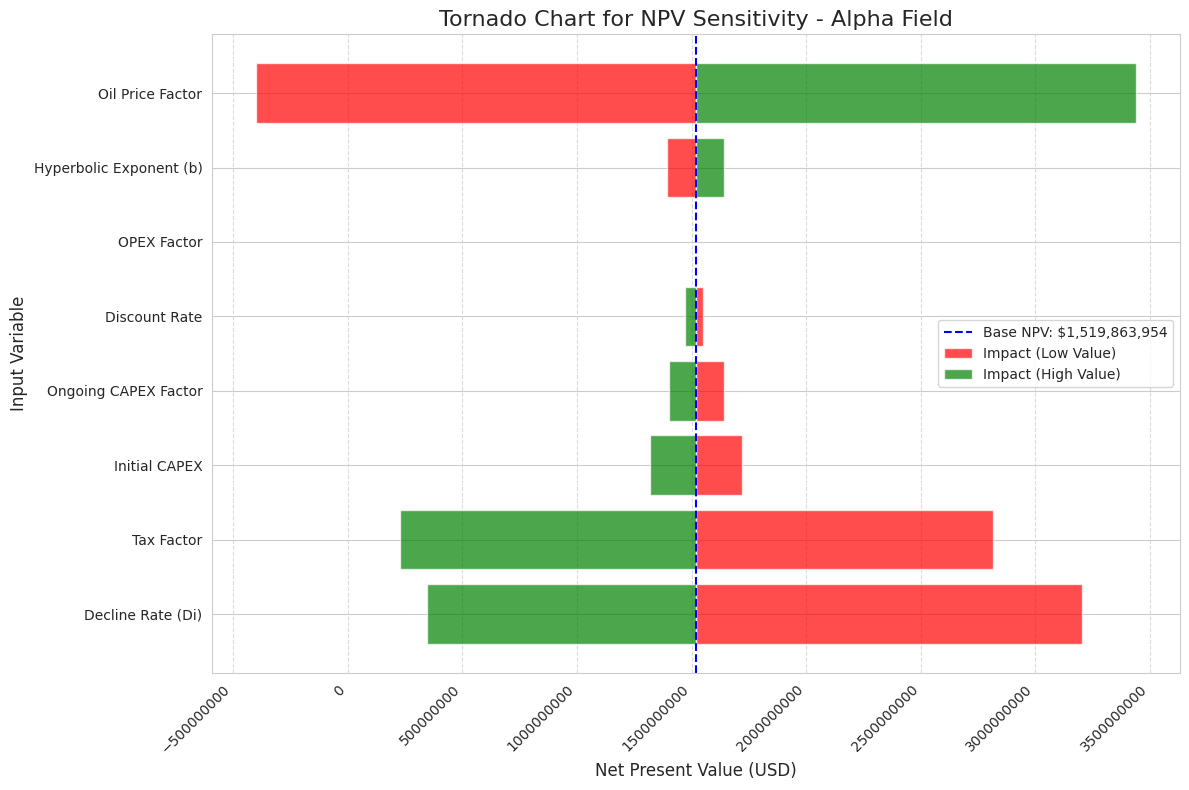

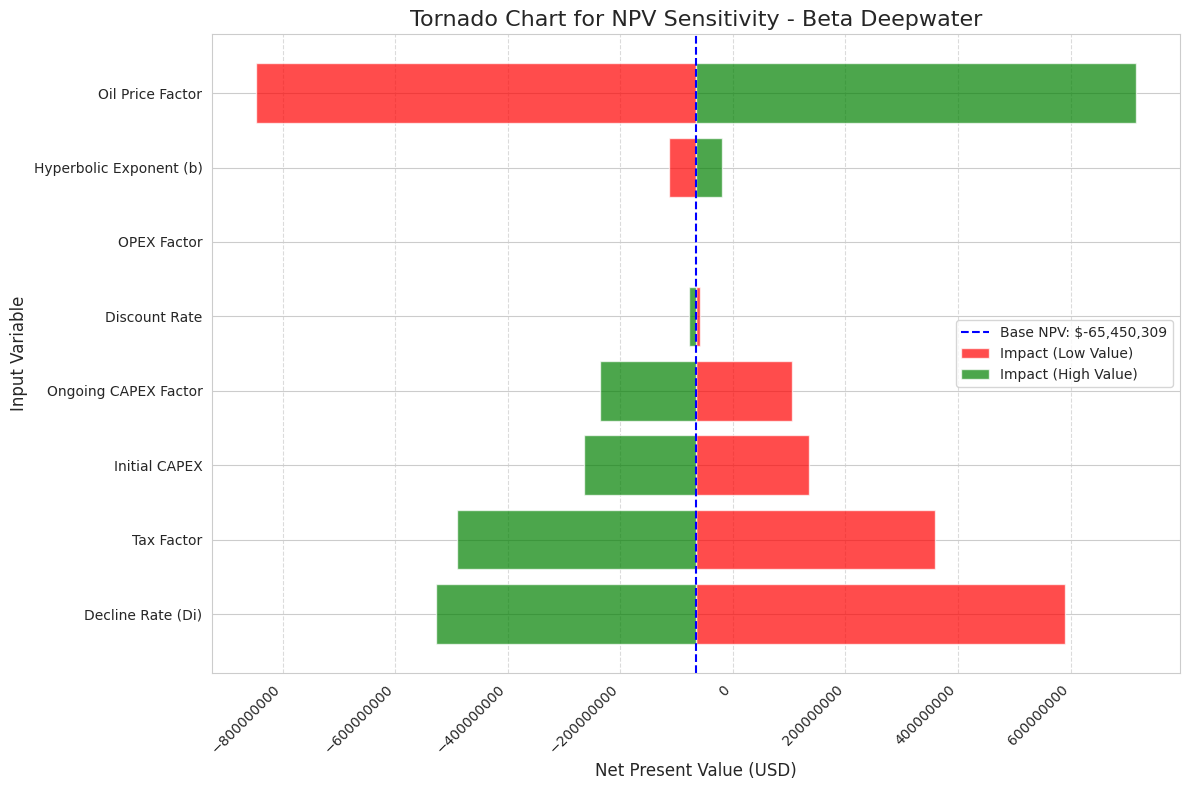

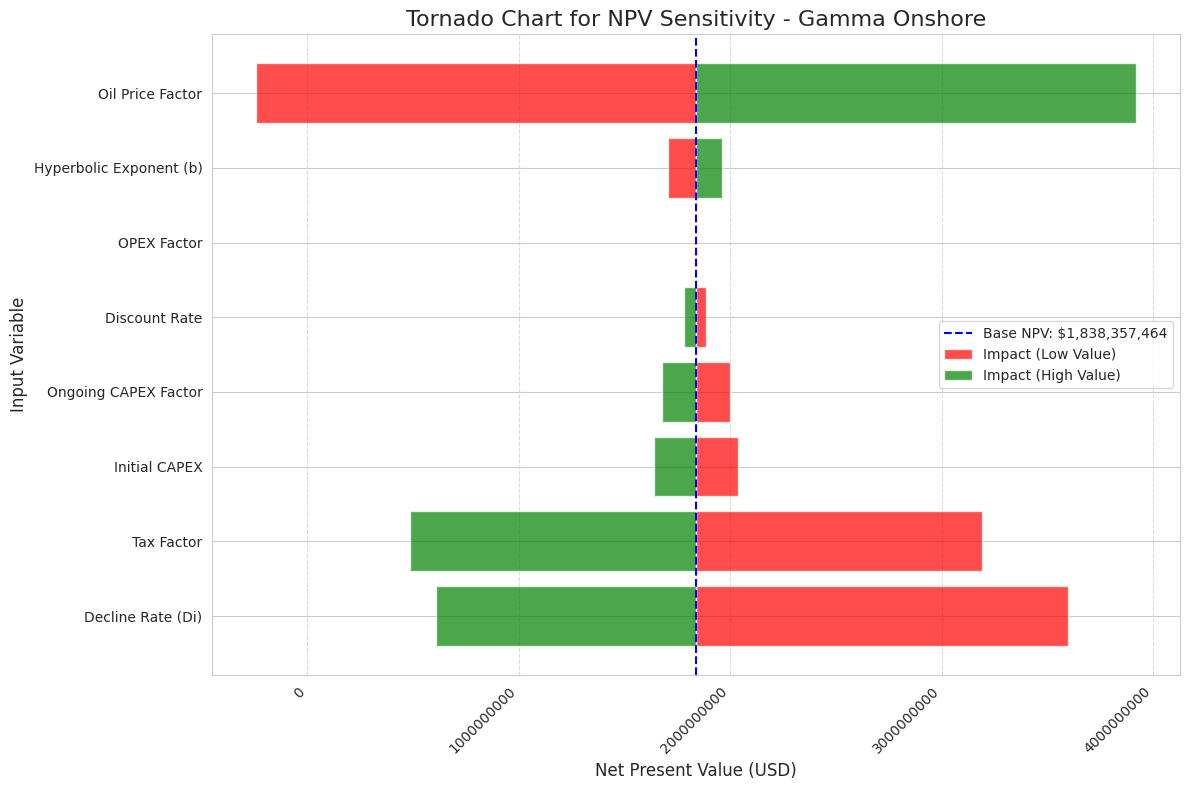

In [ ]:
sns.set_style('whitegrid')

for project_name, df_sens in tornado_results.items():
    plt.figure(figsize=(12, 8))

    # Calculate the base NPV again for consistent centering of the chart
    base_npv = calculate_npv_scenario(
        df[df['Project'] == project_name].copy(),
        base_initial_capex,
        base_discount_rate,
        base_Di,
        base_b,
        base_oil_price_factor,
        base_opex_factor,
        base_ongoing_capex_factor,
        base_tax_factor
    )

    # Create horizontal bar chart
    # Plot the negative impacts (from Base NPV to Low NPV value)
    plt.barh(df_sens['Parameter'], df_sens['Impact_Low'], left=base_npv, color='red', alpha=0.7, label='Impact (Low Value)')
    # Plot the positive impacts (from Base NPV to High NPV value)
    plt.barh(df_sens['Parameter'], df_sens['Impact_High'], left=base_npv, color='green', alpha=0.7, label='Impact (High Value)')

    # Add a vertical line for the base case NPV
    plt.axvline(base_npv, color='blue', linestyle='--', label=f'Base NPV: ${base_npv:,.0f}')

    plt.title(f'Tornado Chart for NPV Sensitivity - {project_name}', fontsize=16)
    plt.xlabel('Net Present Value (USD)', fontsize=12)
    plt.ylabel('Input Variable', fontsize=12)
    plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# **Alpha Field**


The Tornado Chart for Alpha Field shows that the Oil Price Factor has the largest impact on NPV. A 20% decrease in oil price leads to a significant drop in NPV, while a 20% increase results in a substantial rise. The Decline Rate (Di) and Tax Factor also have considerable impacts, with higher decline rates and taxes negatively affecting NPV. Initial CAPEX and Ongoing CAPEX Factor have moderate but expected inverse relationships with NPV. Parameters like Discount Rate, OPEX Factor, and Hyperbolic Exponent (b) have a relatively smaller impact compared to oil price and decline rate.

# **Beta Deepwater**

For Beta Deepwater, the Oil Price Factor is once again the most influential variable, showing the widest range of impact on NPV. The Decline Rate (Di) and Tax Factor also significantly affect the project's profitability, similar to Alpha Field. Initial CAPEX and Ongoing CAPEX Factor are important, but less so than oil price and decline rate. Discount Rate, OPEX Factor, and Hyperbolic Exponent (b) show limited sensitivity in this project.

# **Gamma Onshore**

Similar to the other projects, the Oil Price Factor is the dominant driver of NPV sensitivity for Gamma Onshore. Decline Rate (Di) and Tax Factor follow as the next most impactful variables. Changes in Initial CAPEX and Ongoing CAPEX Factor also exert a noticeable influence. Discount Rate, OPEX Factor, and Hyperbolic Exponent (b) have the least effect on NPV for this project.

# **Overall Takeaways from Tornado Charts:**



*   Oil Price Dominance: Across all three projects, the Oil Price Factor is by far the most critical variable influencing NPV. This highlights the inherent price risk in oil and gas projects.

*   Decline Rate and Tax Impact: The Decline Rate (Di) and Tax Factor consistently rank as the next most significant parameters, emphasizing the importance of accurate production forecasting and understanding the tax regime.
*   CAPEX Sensitivity: Both Initial CAPEX and Ongoing CAPEX Factor demonstrate a clear impact, reinforcing the need for careful capital cost management.


*   Lesser Impact Variables: Discount Rate, OPEX Factor, and Hyperbolic Exponent (b) generally have a smaller influence on NPV within the tested ranges, suggesting that their fluctuations might be less critical for overall project viability compared to the top drivers.

